In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler,OrdinalEncoder,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [5]:
df = pd.read_csv("wine.csv")  

In [6]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [23]:
df.info()
df['Type'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    float64
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(12), int64(2)
memory usage: 19.6 KB


array([1, 2, 3])

In [8]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


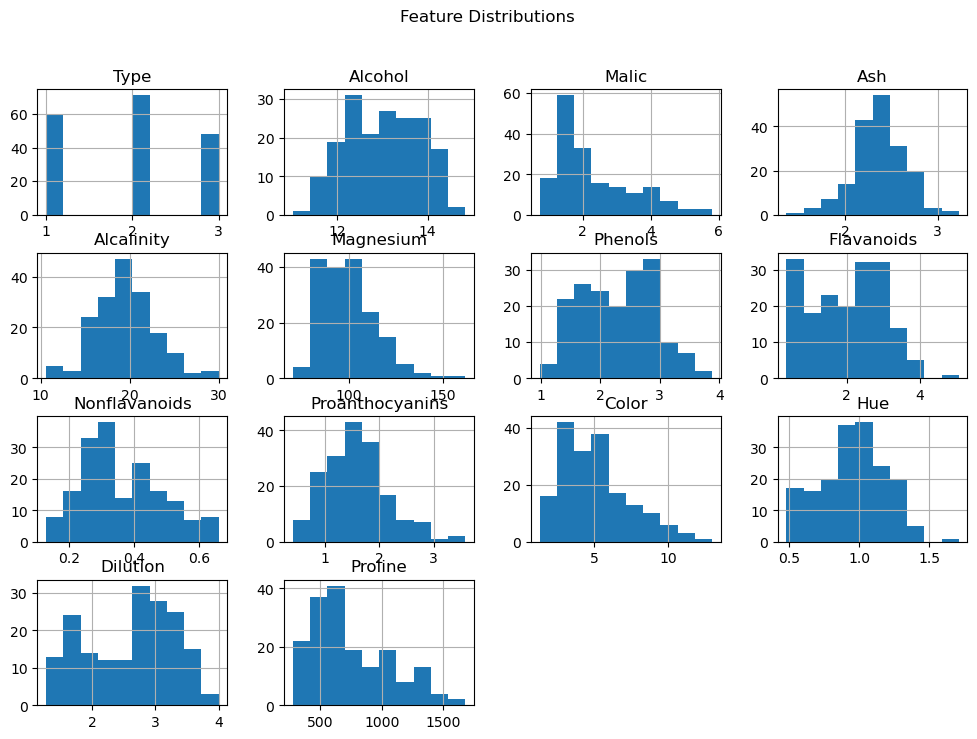

In [9]:
# Histograms
df.hist(figsize=(12,8))
plt.suptitle("Feature Distributions")
plt.show()

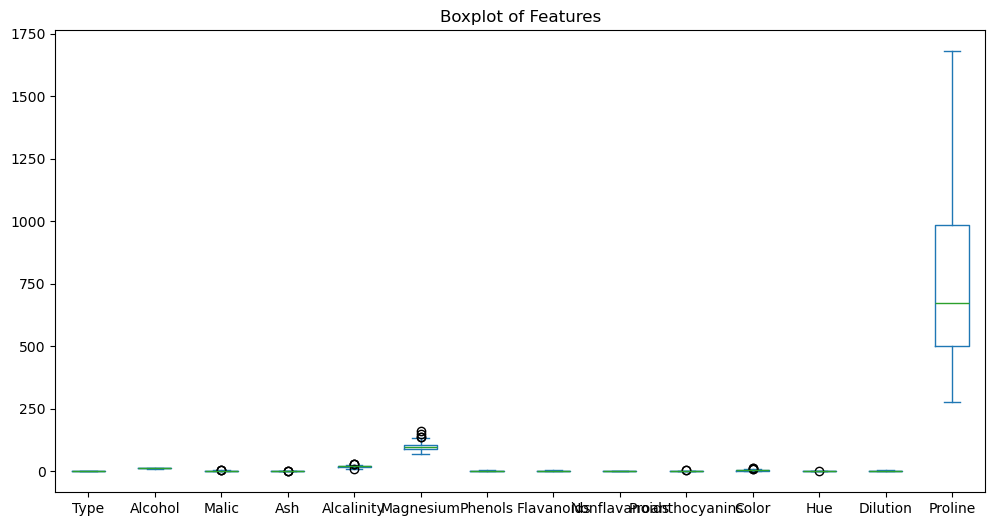

In [10]:
# Boxplots
df.plot(kind='box', figsize=(12,6))
plt.title("Boxplot of Features")
plt.show()

In [11]:
### outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)

<Axes: >

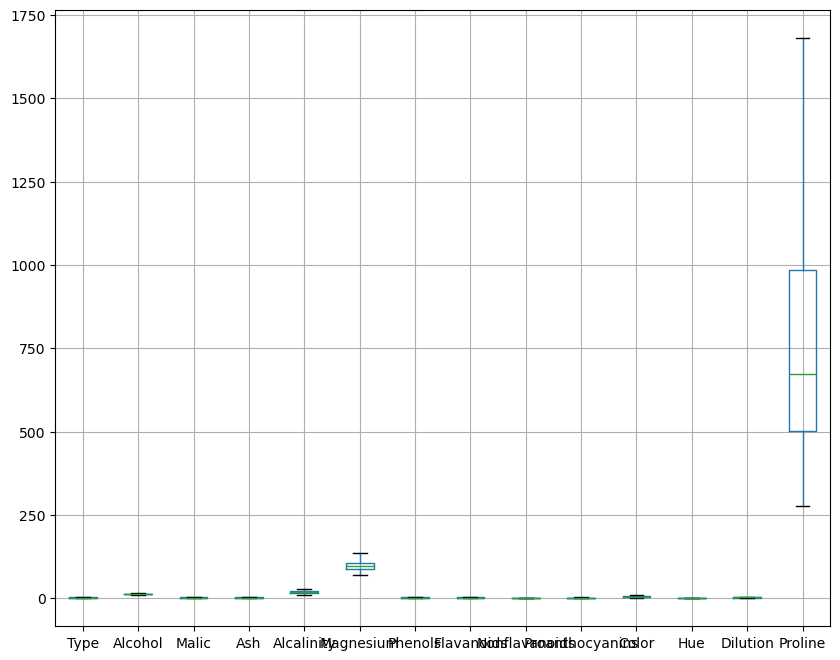

In [14]:
plt.figure(figsize=(10,8))
df.boxplot()

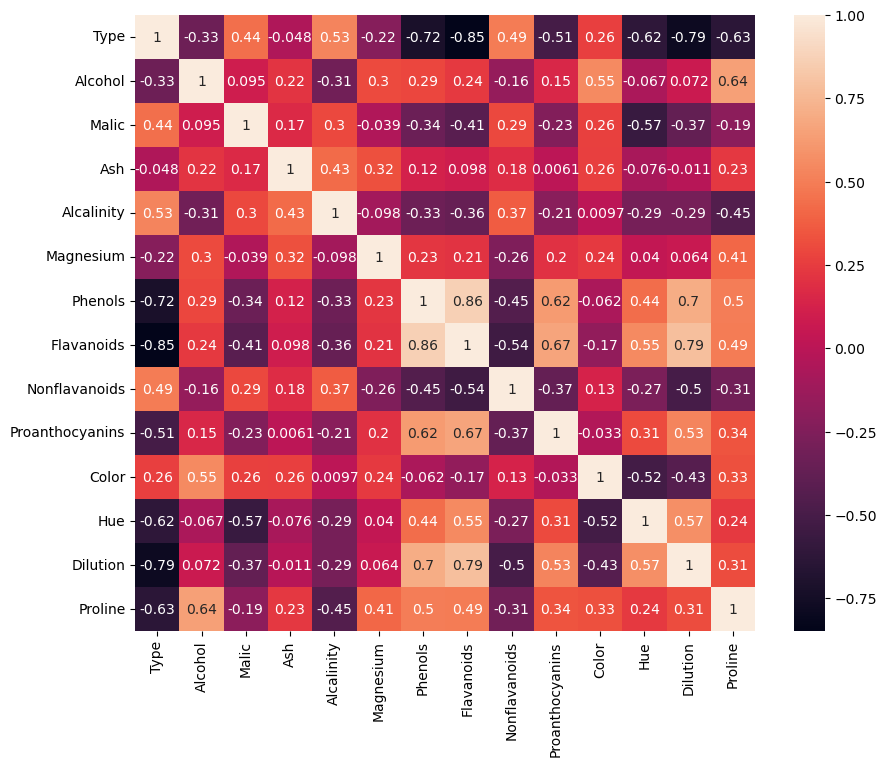

In [22]:
# Correlation Heatmap
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True)
plt.show()

In [28]:
target=df[['Type']]
target

,Type
0,1
1,1
2,1
3,1
4,1
...,...
173,3
174,3
175,3
176,3


In [36]:
feature=df.drop(columns='Type')
feature.columns

Index(['Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')

In [66]:
# Standardize Data
X = df.values
X

array([[1.000e+00, 1.423e+01, 1.710e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.000e+00, 1.320e+01, 1.780e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.000e+00, 1.316e+01, 2.360e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [3.000e+00, 1.327e+01, 4.280e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [3.000e+00, 1.317e+01, 2.590e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [3.000e+00, 1.413e+01, 4.100e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]])

In [67]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [68]:
feature

array([[ 1.51861254, -0.56553422,  0.24064008, ...,  0.36660959,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.50172839, -0.86217567, ...,  0.41076822,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02694849,  1.15331518, ...,  0.32245097,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.77705125, -0.40583812, ..., -1.6205284 ,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.23659622,  0.0124713 , ..., -1.57636978,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.61297912,  1.41951209, ..., -1.53221115,
        -1.42894777, -0.59516041]])

In [69]:
# PCA Fit
pca = PCA()
pca.fit(feature)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


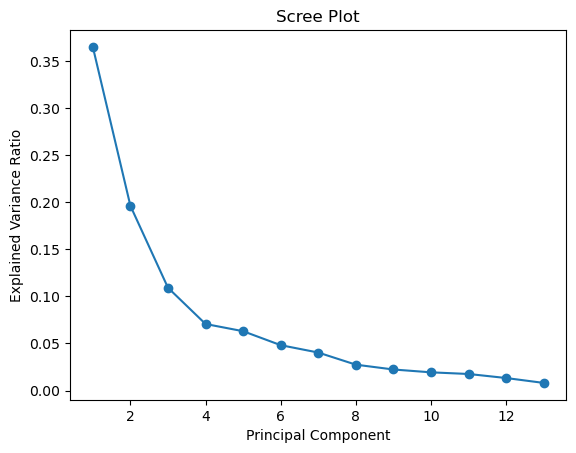

In [70]:
# Scree Plot
plt.plot(np.arange(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.show()

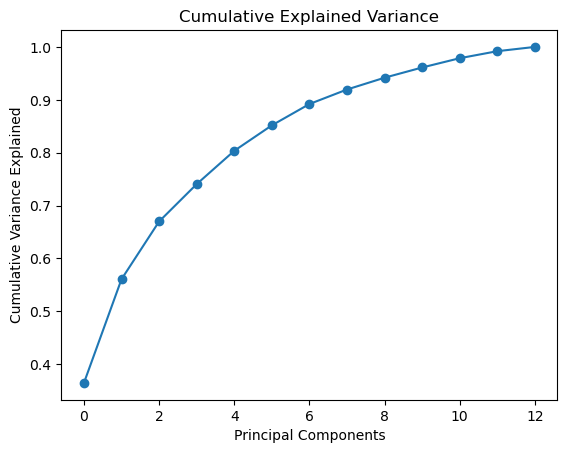

In [71]:
# Cumulative Explained Variance
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.show()

In [72]:
# Choose components 
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_std)

In [73]:
#  3: CLUSTERING (ORIGINAL DATA)
kmeans_orig = KMeans(n_clusters=3, random_state=42).fit(X_std)
labels_orig = kmeans_orig.labels_

sil_orig = silhouette_score(X_std, labels_orig)
db_orig = davies_bouldin_score(X_std, labels_orig)

print("\n--- Clustering on Original Data ---")
print("Silhouette Score:", sil_orig)
print("Davies–Bouldin Index:", db_orig)


--- Clustering on Original Data ---
Silhouette Score: 0.3069772963964642
Davies–Bouldin Index: 1.3098589498896416


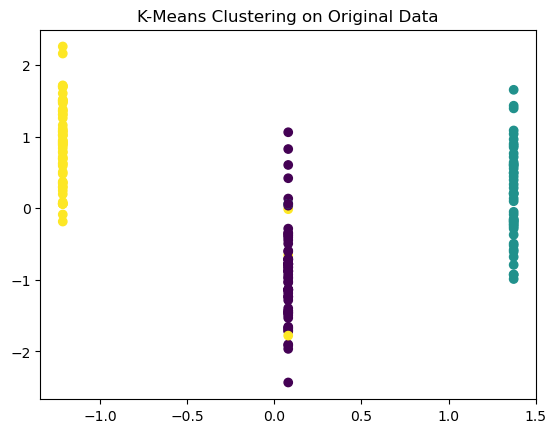

In [74]:
plt.scatter(X_std[:,0], X_std[:,1], c=labels_orig)
plt.title("K-Means Clustering on Original Data")
plt.show()

In [80]:
#  4: CLUSTERING (PCA DATA)
kmeans_pca = KMeans(n_clusters=3, random_state=42).fit(X_pca)
labels_pca = kmeans_pca.labels_

In [81]:
sil_pca = silhouette_score(X_pca, labels_pca)

In [82]:
print("\n Clustering on PCA Data")
print("Silhouette Score:", sil_pca)


 Clustering on PCA Data
Silhouette Score: 0.39722082223085686


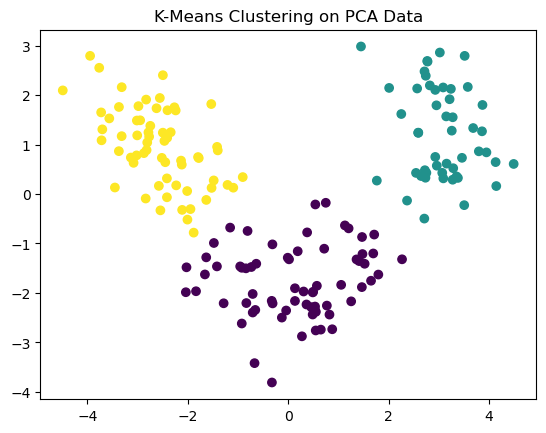

In [83]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca)
plt.title("K-Means Clustering on PCA Data")
plt.show()

In [84]:
#Silhouette Original
sil_orig

0.3069772963964642

In [85]:
#Silhouette PCA
sil_pca

0.39722082223085686

## Comparison of Clustering Results: Original Data vs PCA

The clustering performed on the original dataset and the PCA-transformed data displayed both consistency and noticeable differences. When clustering was applied directly to the original features, the model captured the complete information available in the dataset, forming meaningful groups based on all raw variables. However, this approach resulted in some overlap between clusters due to noise and correlations among the features.

After applying PCA, the clustering results became more compact and distinguishable. PCA removed redundant information and highlighted the directions of highest variance, which helped create clusters with clearer separations. This came with a small trade-off, since compressing information into principal components caused some subtle data patterns to be lost.

## Similarities and Differences in Results

Across both approaches, the fundamental cluster structure remained consistent, meaning the main groups in the data did not change drastically. The primary difference was that clusters formed using PCA data showed stronger separation and better definition, whereas clusters from the original dataset retained more detailed information but suffered from greater overlap and noise.

## Impact of Dimensionality Reduction on Clustering

PCA improved clustering performance by reducing dimensionality, removing feature redundancy, and minimizing noise. The algorithm could then focus on the most impactful components, resulting in more reliable and visually clear clusters. The downside is the loss of direct interpretability because PCA components are combinations of original features, not the original variables themselves.

## Trade-offs Between PCA and Original-Data Clustering

Clustering on the original data offers full interpretability and preserves all information, which is useful when understanding feature contributions is important. However, it can be affected by noisy and correlated attributes. Using PCA enhances cluster separation and reduces computational effort, especially for high-dimensional data, but sacrifices some interpretability and detail.

## Conclusion and Insights

This analysis highlights that PCA is an effective preprocessing technique for clustering, especially when dealing with datasets that have many variables or correlated features. PCA-based clustering produced more compact and visually distinct groups, demonstrating its benefit in improving structure discovery.

In practical applications, PCA is highly useful in fields such as finance, marketing, and biomedical data analysis where dimensionality is high. It enhances clustering clarity and efficiency. Clustering on original data is preferred when interpretability is essential and when the dataset is already low-dimensional.

Overall, PCA should be used when the focus is on improving clustering performance and visualization, while direct clustering on raw features remains valuable when understanding the meaning of each variable within the cluster is the priority.